# **Setup**

* https://towardsdatascience.com/heatmaps-for-time-series/
* https://graphics.wsj.com/infectious-diseases-and-vaccines/

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, Normalize
from matplotlib.cm import ScalarMappable

# **Create Custom Color Map**

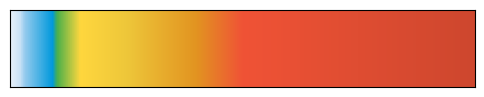

In [2]:
# Normalize RGB colors:
colors = ['#e7f0fa',  # lightest blue
          '#c9e2f6',  # light blue
          '#95cbee',  # blue
          '#0099dc',  # dark blue
          '#4ab04a',  # green
          '#ffd73e',  # yellow
          '#eec73a',  # yellow brown
          '#e29421',  # dark tan
          '#f05336',  # orange
          '#ce472e']  # red

# Create a list of positions for each color in the colormap:
positions = [0, 0.02, 0.03, 0.09, 0.1, 0.15, 0.25, 0.4, 0.5, 1]

# Create a LinearSegmentedColormap (continuous colors):
custom_cmap = LinearSegmentedColormap.from_list('custom_colormap', 
                                                list(zip(positions, 
                                                         colors)))

# Display a colorbar with the custom colormap:
fig, ax = plt.subplots(figsize=(6, 1))

plt.imshow([list(range(256))],
           cmap=custom_cmap, 
           aspect='auto', 
           vmin=0, vmax=255)

plt.xticks([]), plt.yticks([])
plt.show()

# **Data Import**

In [6]:
# Read the csv file into a DataFrame:
url = 'https://bit.ly/3F47ejX'
df_raw = pd.read_csv(url, na_values='-')

print(df_raw.shape)
print(df_raw.columns)
df_raw.head()

(3952, 53)
Index(['YEAR', 'WEEK', 'ALABAMA', 'ALASKA', 'ARIZONA', 'ARKANSAS',
       'CALIFORNIA', 'COLORADO', 'CONNECTICUT', 'DELAWARE',
       'DISTRICT OF COLUMBIA', 'FLORIDA', 'GEORGIA', 'HAWAII', 'IDAHO',
       'ILLINOIS', 'INDIANA', 'IOWA', 'KANSAS', 'KENTUCKY', 'LOUISIANA',
       'MAINE', 'MARYLAND', 'MASSACHUSETTS', 'MICHIGAN', 'MINNESOTA',
       'MISSISSIPPI', 'MISSOURI', 'MONTANA', 'NEBRASKA', 'NEVADA',
       'NEW HAMPSHIRE', 'NEW JERSEY', 'NEW MEXICO', 'NEW YORK',
       'NORTH CAROLINA', 'NORTH DAKOTA', 'OHIO', 'OKLAHOMA', 'OREGON',
       'PENNSYLVANIA', 'RHODE ISLAND', 'SOUTH CAROLINA', 'SOUTH DAKOTA',
       'TENNESSEE', 'TEXAS', 'UTAH', 'VERMONT', 'VIRGINIA', 'WASHINGTON',
       'WEST VIRGINIA', 'WISCONSIN', 'WYOMING'],
      dtype='object')


,YEAR,WEEK,ALABAMA,ALASKA,ARIZONA,ARKANSAS,CALIFORNIA,COLORADO,CONNECTICUT,DELAWARE,...,SOUTH DAKOTA,TENNESSEE,TEXAS,UTAH,VERMONT,VIRGINIA,WASHINGTON,WEST VIRGINIA,WISCONSIN,WYOMING
0,1928,1,3.67,NaN,1.90,4.11,1.38,8.38,4.50,8.58,...,5.69,22.03,1.18,0.4,0.28,NaN,14.83,3.36,1.54,0.91
1,1928,2,6.25,NaN,6.40,9.91,1.80,6.02,9.00,7.30,...,6.57,16.96,0.63,NaN,0.56,NaN,17.34,4.19,0.96,NaN
2,1928,3,7.95,NaN,4.50,11.15,1.31,2.86,8.81,15.88,...,2.04,24.66,0.62,0.2,1.12,NaN,15.67,4.19,4.79,1.36
3,1928,4,12.58,NaN,1.90,13.75,1.87,13.71,10.40,4.29,...,2.19,18.86,0.37,0.2,6.70,NaN,12.77,4.66,1.64,3.64
4,1928,5,8.03,NaN,0.47,20.79,2.38,5.13,16.80,5.58,...,3.94,20.05,1.57,0.4,6.70,NaN,18.83,7.37,2.91,0.91


In [7]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3952 entries, 0 to 3951
Data columns (total 53 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   YEAR                  3952 non-null   int64  
 1   WEEK                  3952 non-null   int64  
 2   ALABAMA               2727 non-null   float64
 3   ALASKA                1359 non-null   float64
 4   ARIZONA               3074 non-null   float64
 5   ARKANSAS              2529 non-null   float64
 6   CALIFORNIA            3664 non-null   float64
 7   COLORADO              3154 non-null   float64
 8   CONNECTICUT           3235 non-null   float64
 9   DELAWARE              2614 non-null   float64
 10  DISTRICT OF COLUMBIA  2446 non-null   float64
 11  FLORIDA               3401 non-null   float64
 12  GEORGIA               2727 non-null   float64
 13  HAWAII                2087 non-null   float64
 14  IDAHO                 2712 non-null   float64
 15  ILLINOIS             

# **Data Processing**

In [8]:
# Convert Values to Numeric
df_raw.iloc[:,2:] = df_raw.iloc[:,2:].apply(pd.to_numeric, errors='coerce')
df_raw.head()

,YEAR,WEEK,ALABAMA,ALASKA,ARIZONA,ARKANSAS,CALIFORNIA,COLORADO,CONNECTICUT,DELAWARE,...,SOUTH DAKOTA,TENNESSEE,TEXAS,UTAH,VERMONT,VIRGINIA,WASHINGTON,WEST VIRGINIA,WISCONSIN,WYOMING
0,1928,1,3.67,NaN,1.90,4.11,1.38,8.38,4.50,8.58,...,5.69,22.03,1.18,0.4,0.28,NaN,14.83,3.36,1.54,0.91
1,1928,2,6.25,NaN,6.40,9.91,1.80,6.02,9.00,7.30,...,6.57,16.96,0.63,NaN,0.56,NaN,17.34,4.19,0.96,NaN
2,1928,3,7.95,NaN,4.50,11.15,1.31,2.86,8.81,15.88,...,2.04,24.66,0.62,0.2,1.12,NaN,15.67,4.19,4.79,1.36
3,1928,4,12.58,NaN,1.90,13.75,1.87,13.71,10.40,4.29,...,2.19,18.86,0.37,0.2,6.70,NaN,12.77,4.66,1.64,3.64
4,1928,5,8.03,NaN,0.47,20.79,2.38,5.13,16.80,5.58,...,3.94,20.05,1.57,0.4,6.70,NaN,18.83,7.37,2.91,0.91


In [17]:
# Aggregate By Year
df = df_raw.groupby(by=['YEAR'],as_index=False).sum().drop('WEEK',axis=1)

print(df.shape)
print(df.columns)
df.head()

(76, 52)
Index(['YEAR', 'ALABAMA', 'ALASKA', 'ARIZONA', 'ARKANSAS', 'CALIFORNIA',
       'COLORADO', 'CONNECTICUT', 'DELAWARE', 'DISTRICT OF COLUMBIA',
       'FLORIDA', 'GEORGIA', 'HAWAII', 'IDAHO', 'ILLINOIS', 'INDIANA', 'IOWA',
       'KANSAS', 'KENTUCKY', 'LOUISIANA', 'MAINE', 'MARYLAND', 'MASSACHUSETTS',
       'MICHIGAN', 'MINNESOTA', 'MISSISSIPPI', 'MISSOURI', 'MONTANA',
       'NEBRASKA', 'NEVADA', 'NEW HAMPSHIRE', 'NEW JERSEY', 'NEW MEXICO',
       'NEW YORK', 'NORTH CAROLINA', 'NORTH DAKOTA', 'OHIO', 'OKLAHOMA',
       'OREGON', 'PENNSYLVANIA', 'RHODE ISLAND', 'SOUTH CAROLINA',
       'SOUTH DAKOTA', 'TENNESSEE', 'TEXAS', 'UTAH', 'VERMONT', 'VIRGINIA',
       'WASHINGTON', 'WEST VIRGINIA', 'WISCONSIN', 'WYOMING'],
      dtype='object')


,YEAR,ALABAMA,ALASKA,ARIZONA,ARKANSAS,CALIFORNIA,COLORADO,CONNECTICUT,DELAWARE,DISTRICT OF COLUMBIA,...,SOUTH DAKOTA,TENNESSEE,TEXAS,UTAH,VERMONT,VIRGINIA,WASHINGTON,WEST VIRGINIA,WISCONSIN,WYOMING
0,1928,334.99,0.0,200.75,481.77,69.22,206.98,634.95,256.02,535.63,...,160.16,315.43,97.35,16.83,334.80,0.0,344.82,195.98,124.61,227.00
1,1929,111.93,0.0,54.88,67.22,72.80,74.24,614.82,239.82,94.20,...,167.77,33.04,71.28,68.90,105.31,0.0,248.60,380.14,1016.54,312.16
2,1930,157.00,0.0,466.31,53.44,760.24,1132.76,112.23,109.25,182.10,...,346.31,179.91,73.12,1044.79,236.69,0.0,631.64,157.70,748.58,341.55
3,1931,337.29,0.0,497.69,45.91,477.48,453.27,790.46,1003.28,832.99,...,212.36,134.79,39.56,29.72,318.40,0.0,197.43,291.38,506.57,60.69
4,1932,10.21,0.0,20.11,5.33,214.08,222.90,348.27,15.98,53.14,...,96.37,68.99,76.58,13.91,1146.08,53.4,631.93,599.65,935.31,242.10


In [18]:
# Reshape DataFrame
df_melted = df.melt(id_vars='YEAR',var_name='State',value_name='Incidence')

print(df_melted.shape)
print(df_melted.columns)
df_melted.head()

(3876, 3)
Index(['YEAR', 'State', 'Incidence'], dtype='object')


,YEAR,State,Incidence
0,1928,ALABAMA,334.99
1,1929,ALABAMA,111.93
2,1930,ALABAMA,157.00
3,1931,ALABAMA,337.29
4,1932,ALABAMA,10.21


In [20]:
# Reshape DataFrame
df_pivot = df_melted.pivot_table(index='State',columns='YEAR',values='Incidence')

# Reversing Rows
df_pivot = df_pivot.iloc[::-1]

print(df_pivot.shape)
print(df_pivot.columns)
df_pivot.head()

(51, 76)
Index([1928, 1929, 1930, 1931, 1932, 1933, 1934, 1935, 1936, 1937, 1938, 1939,
       1940, 1941, 1942, 1943, 1944, 1945, 1946, 1947, 1948, 1949, 1950, 1951,
       1952, 1953, 1954, 1955, 1956, 1957, 1958, 1959, 1960, 1961, 1962, 1963,
       1964, 1965, 1966, 1967, 1968, 1969, 1970, 1971, 1972, 1973, 1974, 1975,
       1976, 1977, 1978, 1979, 1980, 1981, 1982, 1983, 1984, 1985, 1986, 1987,
       1988, 1989, 1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999,
       2000, 2001, 2002, 2003],
      dtype='int64', name='YEAR')


YEAR,1928,1929,1930,1931,1932,1933,1934,1935,1936,1937,...,1994,1995,1996,1997,1998,1999,2000,2001,2002,2003
State,,,,,,,,,,,,,,,,,,,,,
WYOMING,227.00,312.16,341.55,60.69,242.10,249.06,967.44,935.42,57.52,69.91,...,0.00,0.00,0.20,0.61,0.0,0.00,0.00,0.00,0.0,0.0
WISCONSIN,124.61,1016.54,748.58,506.57,935.31,317.48,1332.84,1415.38,126.57,66.55,...,0.04,0.00,0.02,0.00,0.0,0.00,0.00,0.00,0.0,0.0
WEST VIRGINIA,195.98,380.14,157.70,291.38,599.65,303.34,231.80,605.90,63.26,110.04,...,1.98,0.00,0.00,0.05,0.0,0.00,0.00,0.00,0.0,0.0
WASHINGTON,344.82,248.60,631.64,197.43,631.93,155.84,473.84,525.47,463.74,103.34,...,0.00,0.39,0.92,0.27,0.0,0.00,0.00,0.00,0.0,0.0
VIRGINIA,0.00,0.00,0.00,0.00,53.40,351.88,1158.76,727.35,127.83,337.39,...,0.04,0.00,0.01,0.03,0.0,0.25,0.03,0.01,0.0,0.0


# **Data Cleaning**

In [22]:
df_pivot.isna().sum(axis=1).sort_values(ascending=False).head(10)

State
WYOMING          0
WISCONSIN        0
WEST VIRGINIA    0
WASHINGTON       0
VIRGINIA         0
VERMONT          0
UTAH             0
TEXAS            0
TENNESSEE        0
SOUTH DAKOTA     0
dtype: int64

In [25]:
# Create a mask for NaN values:
nan_mask = df_pivot.isna()

# Normalize the data for a shared colormap:
norm = Normalize(df_pivot.min().min(), df_pivot.max().max())

# Apply normalization before masking:
normalized_data = norm(df_pivot)

# Create masked array from normalized data:
masked_data = np.ma.masked_array(normalized_data, mask=nan_mask)

# **Data Visualization**

In [27]:
df_pivot.shape

(51, 76)

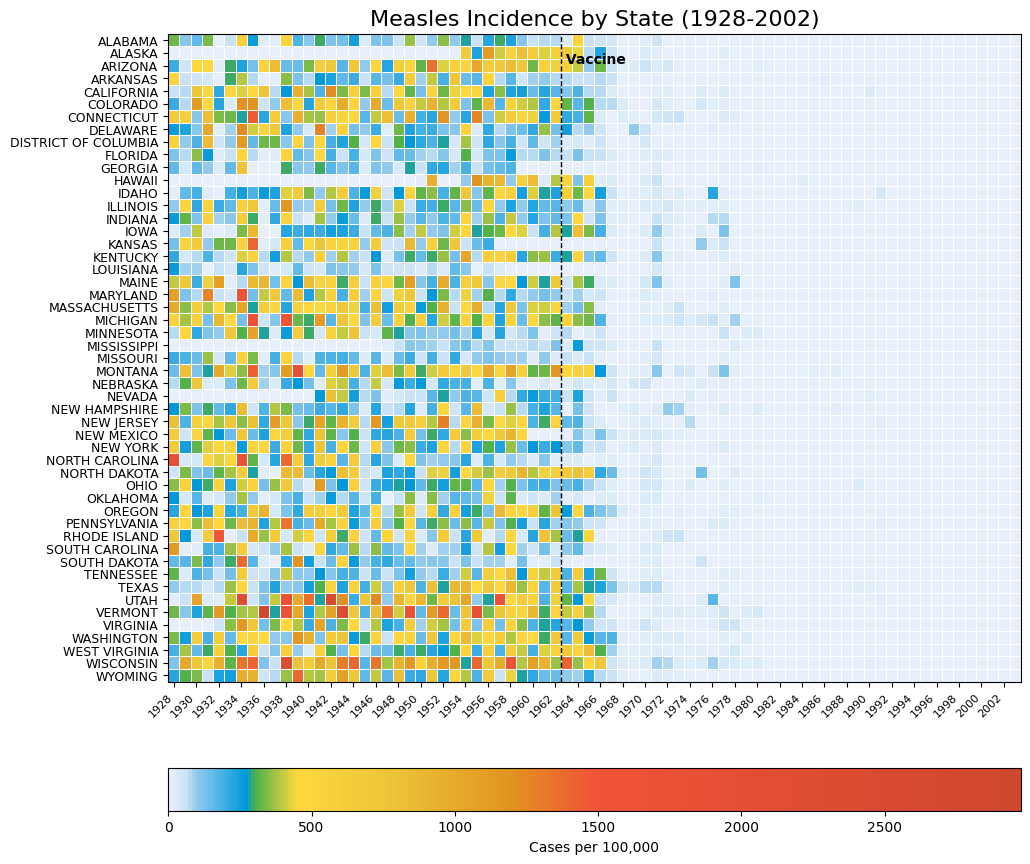

In [44]:
# Create a figure and axis 
multiplier = 0.22
fig, ax = plt.subplots(figsize =(11, df_pivot.shape[0] * multiplier))

states = df_pivot.index.to_list()
years = df_pivot.columns.to_list()

# Create a heatmap with the custom colormap:
im = plt.pcolormesh(masked_data, cmap=custom_cmap, edgecolors='white', linewidth=0.5)
ax.set_title('Measles Incidence by State (1928-2002)', fontsize=16)

# Add vertical line and label for vaccine date:
vaccine_year_index = years.index(1963)
ax.axvline(x=vaccine_year_index, linestyle='--', linewidth=1, color='k')
alaska_index = states.index('ALASKA')
ax.text(vaccine_year_index, alaska_index,' Vaccine',ha='left', va='center', fontweight='bold')

# Set x-ticks and labels:
every_other_year_indices = np.arange(0, len(years), 2) + 0.5
ax.set_xticks(every_other_year_indices)
ax.set_xticklabels(years[::2], rotation=45, ha='right', fontsize=8)

# Adjust labels on y-axis:
ax.set_yticks(np.arange(len(states)) + 0.5)  # Center ticks in cells
ax.set_yticklabels(states, fontsize=9)

# Add a colorbar:
cbar = fig.colorbar(ScalarMappable(norm=norm, cmap=custom_cmap), 
                    ax=ax, orientation='horizontal', pad=0.1, 
                    label='Cases per 100,000')
cbar.ax.xaxis.set_ticks_position('bottom')

plt.savefig('measles_pcolormesh_nan.png', dpi=600, bbox_inches='tight')
plt.show()